In [1]:
import numpy as np
import pandas as pd
import os, sys
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from typing import Dict, List
sys.path.append('../')
from config import JUNCTIONS, get_file_paths, get_file_paths_list, reverse_complement
from get_logits import predicted_masked_tokens, chunks

In [2]:
tokenizer = AutoTokenizer.from_pretrained('kuleshov-group/PlantCaduceus_l32')

In [3]:
labels_dict = {}
for idx, junction in enumerate(JUNCTIONS):
    label = pd.read_csv(get_file_paths('labels', '../../../results/pseudo_gene/splice_junctions/')[junction], sep='\t')
    for model in ['pcv1', 'pcv2_1', 'pcv2_2', 'pcv2_3']:
        predicted_codon, true_tokens = predicted_masked_tokens(model, idx, tokenizer, 
                                                               base_dir='../../../results/pseudo_gene/outputs', 
                                                               chunk_size=None, JUNCTIONS=JUNCTIONS)
        label[f'predicted_codon_{model}'] = predicted_codon
    label['true_tokens'] = true_tokens
    # gpn
    logits = np.loadtxt(get_file_paths('gpn', '../../../results/pseudo_gene/outputs')[junction])
    predicted_tokens = np.argmax(logits, axis = -1)
    sequence = ['ACGT'[i] for i in predicted_tokens]
    
    if junction in ['start_sites', 'stop_sites']:
        predicted_codon = [''.join(sequence[i:i+3]) for i in range(0, len(sequence), 3)]
    else:
        predicted_codon = [''.join(sequence[i:i+2]) for i in range(0, len(sequence), 2)]
    label['predicted_codon_gpn'] = predicted_codon
    
    # for Evo2 fwd
    predicted_codon = pd.read_csv(get_file_paths('evo2_fwd', '../../../results/pseudo_gene/outputs')[junction], sep='\t', header=None)
    label['predicted_codon_evo2_fwd'] = predicted_codon[0]
    # for Evo2 rc
    predicted_codon = pd.read_csv(get_file_paths('evo2_rc', '../../../results/pseudo_gene/outputs')[junction], sep='\t', header=None)
    label['predicted_codon_evo2_rc'] = predicted_codon[0]
    
    label['Label'] = 'All'
    labels_dict[junction] = label

In [4]:
labels_dict['start_sites']['predicted_codon_evo2_rc'].value_counts()

predicted_codon_evo2_rc
CAT    17275
CGC     2926
GGC     2917
CGG     1057
AAA      940
       ...  
TTA       26
TCA       25
ACT       23
CTA       22
ACA       21
Name: count, Length: 64, dtype: int64

In [5]:
label_order = ['All']
def calculate_accuracies(df, order=label_order):
    results = {}
    for label in order: 
        if label in df['Label'].values:
            group = df[df['Label'] == label].copy()
            
            # Calculate accuracy for PlantCAD models
            pcv1_acc = (group['predicted_codon_pcv1'] == group['true_tokens']).mean()
            pcv2_1_acc = (group['predicted_codon_pcv2_1'] == group['true_tokens']).mean()
            pcv2_2_acc = (group['predicted_codon_pcv2_2'] == group['true_tokens']).mean()
            pcv2_3_acc = (group['predicted_codon_pcv2_3'] == group['true_tokens']).mean()
            gpn_acc = (group['predicted_codon_gpn'] == group['true_tokens']).mean()
            
            # Calculate accuracy for Evo2
            evo2_fwd_acc = (group['predicted_codon_evo2_fwd'] == group['true_tokens']).mean()
            group.loc[:, 'true_tokens_rc'] = group['true_tokens'].apply(reverse_complement)
            evo2_rc_acc = (group['predicted_codon_evo2_rc'] == group['true_tokens_rc']).mean()
            
            # Calculate combined accuracy
            evo2_either_acc = ((group['predicted_codon_evo2_fwd'] == group['true_tokens']) | 
                              (group['predicted_codon_evo2_rc'] == group['true_tokens_rc'])).mean()
            
            results[label] = {
                'pcv1': pcv1_acc,
                'pcv2_1': pcv2_1_acc,
                'pcv2_2': pcv2_2_acc,
                'pcv2_3': pcv2_3_acc,
                'evo2_fwd': evo2_fwd_acc,
                'evo2_rc': evo2_rc_acc,
                'evo2_either': evo2_either_acc,
                'gpn': gpn_acc
            }
    
    return results

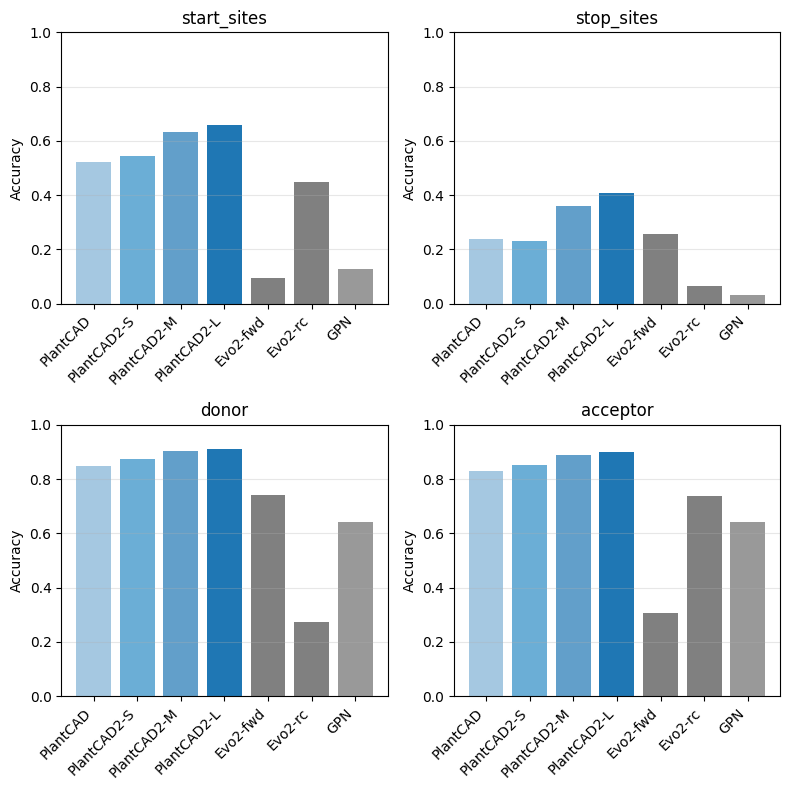

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes_flat = axes.flatten()


colors = ['#1f77b466', '#6baed6', '#1f77b4b3', '#1f77b4ff',  '#808080', '#808080', '#999999', '#d3d3d3']

models = ['pcv1', 'pcv2_1', 'pcv2_2', 'pcv2_3', 'evo2_fwd', 'evo2_rc', 'gpn']
model_labels = ['PlantCAD', 'PlantCAD2-S', 'PlantCAD2-M', 'PlantCAD2-L', 'Evo2-fwd', 'Evo2-rc', 'GPN']

for idx, (dataset_name, df) in enumerate(labels_dict.items()):
    ax = axes_flat[idx]
    accuracies = calculate_accuracies(df)
    
    # Get accuracy values for the single class (assuming it's 'All' or first available)
    class_name = list(accuracies.keys())[0]  # Get first available class
    acc_values = [accuracies[class_name][model] for model in models]
    
    # Simple bar plot with models as x-axis
    bars = ax.bar(range(len(models)), acc_values, color=colors, width=0.8)
    ax.grid(True, alpha = 0.3, axis = 'y')
    
    # Add value labels on bars
    # for bar, acc in zip(bars, acc_values):
    #     if acc > 0:
    #         ax.annotate(f'{acc:.2f}',
    #                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
    #                    xytext=(0, 3), textcoords="offset points",
    #                    ha='center', va='bottom', fontsize=8)
    
    ax.set_ylabel('Accuracy')
    ax.set_title(dataset_name)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(model_labels, rotation=45, ha='right')
    ax.set_ylim(0, 1)

plt.subplots_adjust(left=0.08, right=0.95, top=0.92, bottom=0.15, 
                   wspace=0.3, hspace=0.4)
plt.tight_layout()
plt.savefig('Token_accuracy_comparison.pdf', format = 'pdf', bbox_inches = 'tight')
plt.show()

In [7]:
# Collect all the data
data_for_tsv = []

for dataset_name, df in labels_dict.items():
    accuracies = calculate_accuracies(df)
    
    # Get accuracy values for the single class
    class_name = list(accuracies.keys())[0]
    acc_values = [accuracies[class_name][model] for model in models]
    
    # Add to data collection
    row = {'Dataset': dataset_name}
    for model, model_label, acc in zip(models, model_labels, acc_values):
        row[model_label] = acc
    data_for_tsv.append(row)

# Create DataFrame and save as TSV
df_results = pd.DataFrame(data_for_tsv)
df_results.to_csv('token_accuracy_results.tsv', sep='\t', index=False, float_format='%.4f')